# EOS posterior — results and derived quantities

Post-processing on the `.pt` file produced by `run_sampling.py`.
Computes, per posterior sample and then as weighted 68% CI summaries:

 * pressure $P(n_B)$ and energy density $\varepsilon(n_B)$;
 * polytropic index $\gamma = \mathrm{d}\ln P / \mathrm{d}\ln\varepsilon$, trace anomaly $\Delta = 1/3 - P/\varepsilon$, composite measure $d_c = \sqrt{\Delta^2 + (\Delta')^2}$;
 * speed of sound: peak $c_{s,\mathrm{max}}^2$ and its location $n_\mathrm{peak}$, plus $c_s^2(n_\mathrm{TOV})$ and $c_s^2(8\,n_0)$;
 * TOV-centre conformality: $\gamma$, $\Delta$, $d_c$, $c_s^2$ at $n_\mathrm{TOV}$, with $n_\mathrm{TOV}/n_0$;
 * symmetry-energy slope $L$ (text method, in `analysis.diagnostics`);
 * fiducial NS quantities $R$ and $\Lambda$ at $1.4 / 1.6 / 2.08\,M_\odot$, and $M_\mathrm{TOV}$;
 * phase-transition probability $P_\mathrm{PT}$ and Bayes factor $\mathrm{BF}$ (PT vs no-PT) with bootstrap uncertainty.

Also builds external comparison bands vs Annala et al. 2023 (GP + C4 ensembles), a master table against the literature, and the figures.

## 1. Training curves

Training and validation loss (upper panel, log scale) and the learning-rate
schedule (lower panel) for the run logged in `resume_training_log.csv`
(100 epochs, cosine decay after a 2-epoch linear warmup).
The inset magnifies the first 15 epochs; the star marks the best EMA
validation loss, $0.043925$ at epoch 83.


  training log: dropped 1 duplicated epoch row(s) at [26] (kept the post-resume values)
  Training curves saved to plots/training_curves.png


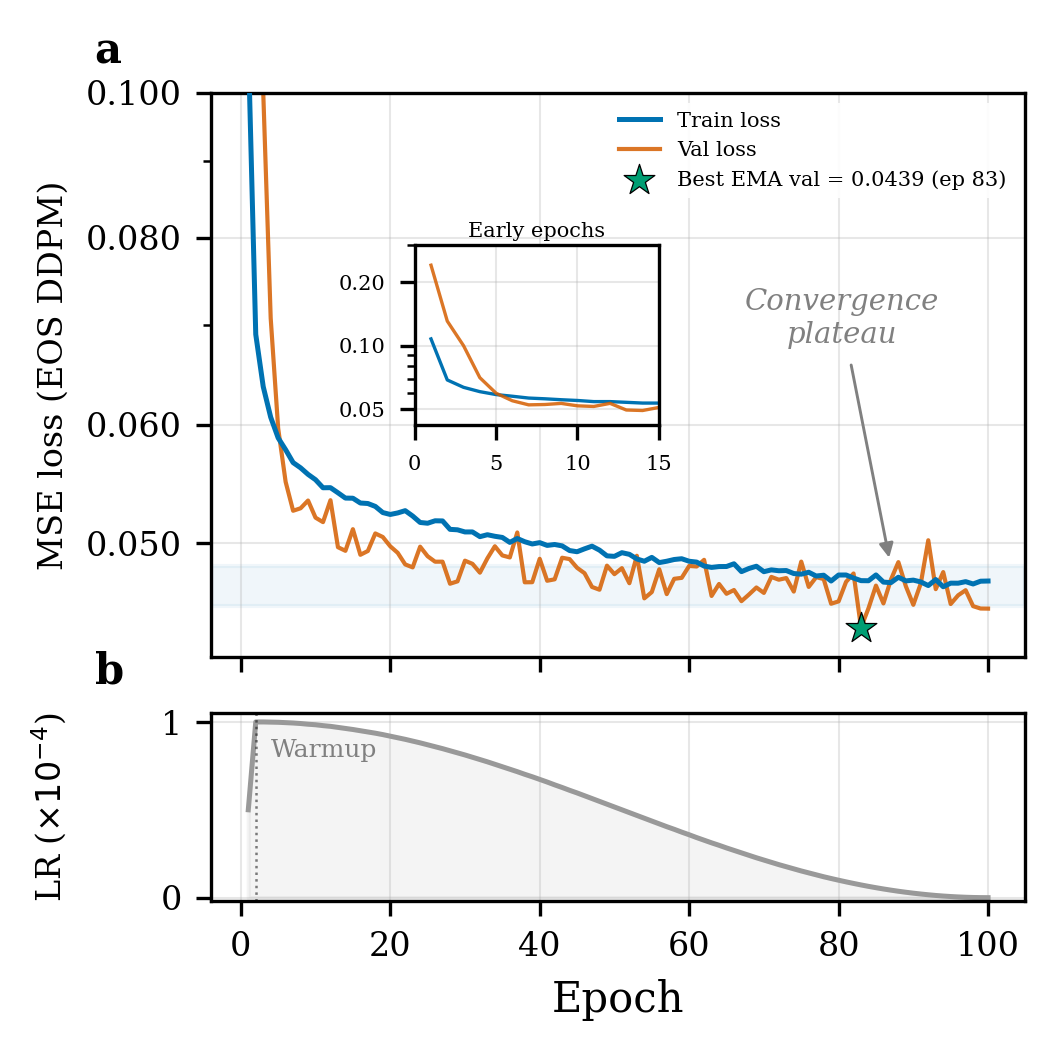

In [1]:
import sys, os
PARENT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if PARENT not in sys.path:
    sys.path.insert(0, PARENT)

from analysis.plots import plot_training_curves

LOG_PATH = "res_finale_baseline/resume_training.log.csv"      
fig, (ax_loss, ax_lr) = plot_training_curves(
    LOG_PATH,
    save_path="plots/training_curves.png",
    y_label=r"MSE loss (EOS DDPM)",       
)

## 2. Imports and configuration

In [2]:
import sys, os
PARENT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if PARENT not in sys.path:
    sys.path.insert(0, PARENT)

import numpy as np
import torch
import matplotlib.pyplot as plt

from analysis import (
    compute_P_eps_ensemble,
    compute_diagnostics,
    fiducial_NS_quantities,
    print_fiducial_table,
    phase_transition_diagnostic,
)
from eos_sampling.plotting import plot_nested_posteriors

OUTPUT_PATH = "res_finale_baseline/eos_EFT_posterior_kdenicer.pt"

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

def plot_path(name):
    """Return absolute output path inside PLOTS_DIR for a given figure name."""
    return os.path.join(PLOTS_DIR, name)

NESTED_PLOT_PATH = plot_path("eos_EFT_posterior_nested.png")


Q_LOW, Q_HIGH = 0.16, 0.84
N0_DEFAULT    = 0.16


# ---------------------------------------------------------------------------
# Weighted-quantile helpers used throughout.
# ---------------------------------------------------------------------------
def _wquant(values, weights, q, min_count=5):
    """Scalar weighted quantile via linear interpolation on the cumulative weight curve."""
    v = np.asarray(values, float); w = np.asarray(weights, float)
    m = np.isfinite(v) & (w > 0)
    if m.sum() < min_count:
        return float("nan")
    v = v[m]; w = w[m]; o = np.argsort(v); cw = np.cumsum(w[o]) / w[o].sum()
    return float(np.interp(q, cw, v[o]))

def _wband(arr, weights, qs=(0.16, 0.5, 0.84), min_count=5):
    """Per-column weighted 16/50/84 band across samples (NaN where < min_count valid)."""
    arr = np.asarray(arr, float); L = arr.shape[1]
    out = np.full((len(qs), L), np.nan)
    for j in range(L):
        for k, q in enumerate(qs):
            out[k, j] = _wquant(arr[:, j], weights, q, min_count)
    return out

def _weighted_quantiles(values, weights, qs=(0.16, 0.50, 0.84)):
    """Weighted quantiles (min_count=2); matches reweighting.weighted_quantile."""
    return tuple(_wquant(values, weights, q, min_count=2) for q in qs)

def _diag_cross(xv, yv, thr):
    """First nB/nsat where median curve yv drops from >=thr to <thr (linear interp)."""
    for k in range(1, len(xv)):
        a, b = yv[k-1], yv[k]
        if np.isfinite(a) and np.isfinite(b) and a >= thr > b:
            return xv[k-1] + (thr - a) * (xv[k] - xv[k-1]) / (b - a)
    return np.nan


## 3. Load the saved results

In [3]:
out = torch.load(OUTPUT_PATH, weights_only=False)

print(f"Loaded {OUTPUT_PATH}")
print(f"  N drawn          : {out.get('n_drawn', '?')}")
print(f"  N post-causality : {out.get('n_post_filter', '?')}")
print(f"  ESS              : {out['reweighting']['ESS']:.1f}")

samples_phys = out["samples_phys"]
nB_grid      = out["nB_grid"]
weights      = out["reweighting"]["weights"]
M_arr        = out["reweighting"]["M"]
R_arr        = out["reweighting"]["R"]
Lambda_arr   = out["reweighting"]["Lambda"]

print(f"  samples_phys shape : {tuple(samples_phys.shape)}")
print(f"  cached M shape     : {M_arr.shape}")

# --- thermodynamic reference point used by the pipeline (chEFT) ---
REF = out["ref_point"]
print(f"  ref point          : eps_ref={REF['eps_ref']:.4f}, "
      f"P_ref={REF['P_ref']:.4f} MeV/fm^3  [{REF.get('source','')}]")


# ---- anchor 1-sigma errors, used by the Nature diagnostics figure ----
#      (cs2_cov -> sqrt(diag), else cs2_sigma, else None)
if out.get("cs2_cov") is not None:
    _cov = out["cs2_cov"]
    _cov_np = _cov.numpy() if hasattr(_cov, "numpy") else np.asarray(_cov)
    cs2_err = np.sqrt(np.clip(np.diag(_cov_np), 0.0, None))
elif out.get("cs2_sigma") is not None:
    _sig = out["cs2_sigma"]
    cs2_err = _sig.numpy() if hasattr(_sig, "numpy") else np.asarray(_sig)
else:
    cs2_err = None


Loaded res_finale_baseline/eos_EFT_posterior_kdenicer.pt
  N drawn          : 100000
  N post-causality : 89513
  ESS              : 4187.3
  samples_phys shape : (89513, 200)
  cached M shape     : (89513, 40)
  ref point          : eps_ref=75.8598, P_ref=0.4213 MeV/fm^3  [analysis/chEFT/cs2_BETAEQ_Lambda-500_refpoint_mean.npy]


## 4. Nested posteriors

How each layer of conditioning tightens the posterior band:
$\chi$-EFT inpainting $\rightarrow$ + astro (NICER + GW + $M_\mathrm{max}$)
$\rightarrow$ + pQCD. Per-term effective sample sizes first, then the figure.


In [4]:
# Per-term effective sample sizes (the joint ESS and the N counts are printed
# with the load in section 3).
r  = out["reweighting"]
Nd = out.get("n_drawn", "?")
Np = out.get("n_post_filter", "?")
if isinstance(Np, int) and Np > 0:
    print(f"Joint ESS / N_post_filter = {100.0 * r['ESS'] / Np:.1f}%")
if isinstance(Nd, int) and Nd > 0:
    print(f"Joint ESS / N_drawn       = {100.0 * r['ESS'] / Nd:.1f}%")
print("Per-term ESS:")
print(f"   NICER  = {r['ESS_nicer']:6.1f}")
print(f"   GW     = {r['ESS_gw']:6.1f}")
print(f"   M_max  = {r['ESS_mmax']:6.1f}")
if "ESS_pqcd" in r:
    print(f"   pQCD   = {r['ESS_pqcd']:6.1f}")


Joint ESS / N_post_filter = 4.7%
Joint ESS / N_drawn       = 4.2%
Per-term ESS:
   NICER  = 5258.9
   GW     = 20262.8
   M_max  = 10976.4
   pQCD   = 24501.0


  Nested-posteriors plot saved to plots/eos_EFT_posterior_nested.png


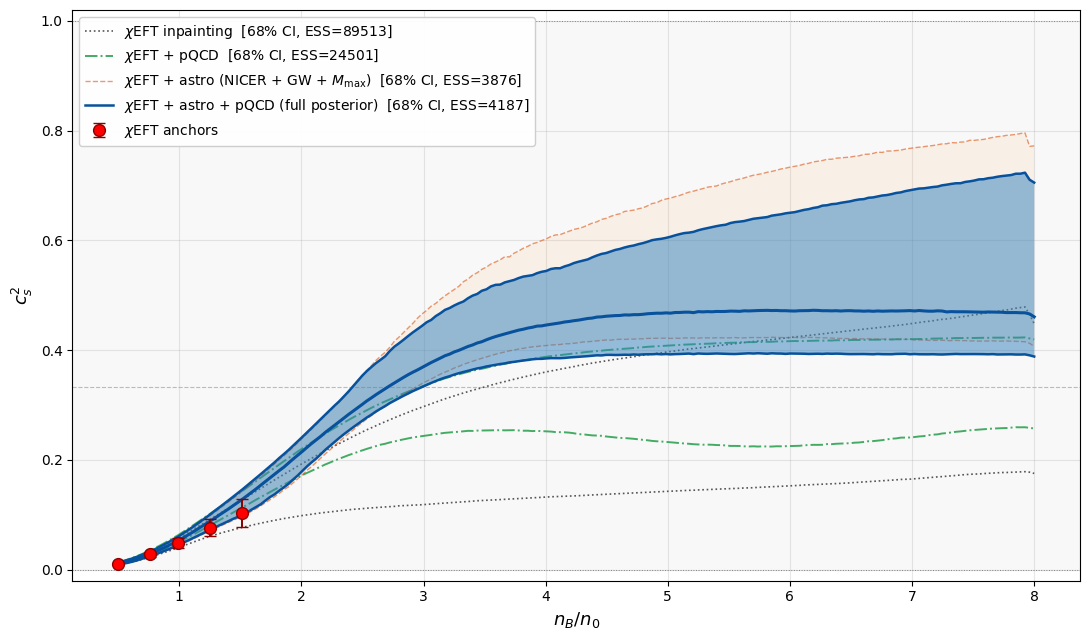

In [5]:
fig_nested, ax_nested = plot_nested_posteriors(
    out,
    q_low     = Q_LOW,
    q_high    = Q_HIGH,
    save_path = NESTED_PLOT_PATH,
    title     = "",   
)
plt.show()


## 5. Pressure and energy density

Heun integration of the first-law system, reusing
`eos_sampling.reweighting.thermodynamic_integration_np`.

In [6]:
P_arr, eps_arr = compute_P_eps_ensemble(
    samples_phys, nB_grid,
    eps_ref=REF["eps_ref"], P_ref=REF["P_ref"])

# Sanity check -- shapes and physical ranges
print(f"P_arr   shape={P_arr.shape}, "
      f"range=[{P_arr.min():.2f}, {P_arr.max():.1f}] MeV/fm^3")
print(f"eps_arr shape={eps_arr.shape}, "
      f"range=[{eps_arr.min():.1f}, {eps_arr.max():.1f}] MeV/fm^3")


  compute_P_eps_ensemble: integrated 89513 samples on 200-point n_B grid
    P   range:  [0.42, 2394.01] MeV/fm^3
    eps range:  [75.86, 2727.14] MeV/fm^3
P_arr   shape=(89513, 200), range=[0.42, 2394.0] MeV/fm^3
eps_arr shape=(89513, 200), range=[75.9, 2727.1] MeV/fm^3


## 6. Polytropic index, trace anomaly, $d_c$

Closed-form algebraic transformations of the per-sample
$(P, \varepsilon, c_s^2)$ arrays:

* $\gamma = c_s^2\,\varepsilon / P$,
* $\Delta = 1/3 - P/\varepsilon$,
* $\Delta' = P/\varepsilon - c_s^2$  (analytic; from $\Delta' = \mathrm{d}\Delta/\mathrm{d}\ln\varepsilon$),
* $d_c = \sqrt{\Delta^2 + (\Delta')^2}$.

In [7]:
gamma_arr, Delta_arr, dc_arr = compute_diagnostics(
    P_arr, eps_arr, samples_phys)

print(f"  gamma   range : [{gamma_arr.min():.2f}, {gamma_arr.max():.2f}]")
print(f"  Delta   range : [{Delta_arr.min():.3f}, {Delta_arr.max():.3f}]")
print(f"  d_c     range : [{dc_arr.min():.3f}, {dc_arr.max():.3f}]")


  gamma   range : [0.00, 37.24]
  Delta   range : [-0.545, 0.329]
  d_c     range : [0.000, 0.992]


In [8]:
# ============================================================================
#  Conformality diagnostics from the weighted-median bands of gamma, Delta, d_c
# ============================================================================
_xd = np.asarray(nB_grid, float)                       # nB / nsat
_G  = _wband(gamma_arr, weights)
_D  = _wband(Delta_arr, weights)
_C  = _wband(dc_arr,    weights)

print("=" * 60)
print("  CONFORMALITY DIAGNOSTICS  (weighted-median band, 68% CI)")
print("=" * 60)
_jpk = np.nanargmax(_G[1])
print(f"  gamma peak (median) = {_G[1][_jpk]:.2f}  "
      f"[68%: {_G[0][_jpk]:.2f}, {_G[2][_jpk]:.2f}]  at nB/nsat = {_xd[_jpk]:.2f}")
print(f"  gamma median crosses 1.75 (Annala QM criterion) at nB/nsat = "
      f"{_diag_cross(_xd, _G[1], 1.75):.2f}")
print(f"  gamma median at top of grid (nB/nsat = {_xd[-1]:.0f}) = {_G[1][-1]:.2f}")
for _nb in (0.5, 8.0):
    print(f"  Delta at {_nb:>4} nsat : median {np.interp(_nb,_xd,_D[1]):+.3f}  "
          f"68% [{np.interp(_nb,_xd,_D[0]):+.3f}, {np.interp(_nb,_xd,_D[2]):+.3f}]")
_below = np.isfinite(_C[1]) & (_C[1] < 0.2)
if _below.any():
    print(f"  d_c median < 0.2 for nB/nsat in "
          f"[{_xd[_below].min():.2f}, {_xd[_below].max():.2f}]")
else:
    print("  d_c median never drops below 0.2")
print("=" * 60)


  CONFORMALITY DIAGNOSTICS  (weighted-median band, 68% CI)
  gamma peak (median) = 3.10  [68%: 2.92, 3.22]  at nB/nsat = 1.14
  gamma median crosses 1.75 (Annala QM criterion) at nB/nsat = 4.44
  gamma median at top of grid (nB/nsat = 8) = 1.24
  Delta at  0.5 nsat : median +0.328  68% [+0.328, +0.328]
  Delta at  8.0 nsat : median -0.044  68% [-0.157, +0.008]
  d_c median < 0.2 for nB/nsat in [4.68, 8.00]


## 7. Phase-transition posterior

Posterior probability that $c_s^2$ dips below threshold inside the
core density window, plus the prior probability for the same shape
test (uniform weights on the causality-filtered ensemble).
The ratio gives a Bayes-factor-like quantity for the presence vs.
absence of a phase-transition feature.

In [9]:
diag_post = phase_transition_diagnostic(
    samples_phys, weights, nB_grid,
    threshold=0.1, window=(1.5, 6.0))

# Prior diagnostic: same threshold/window, uniform weights.
N = samples_phys.shape[0]
diag_prior = phase_transition_diagnostic(
    samples_phys, np.ones(N), nB_grid,
    threshold=0.1, window=(1.5, 6.0))

P_post  = diag_post["P_PT"]
P_prior = diag_prior["P_PT"]
print(f"  P_PT (posterior) = {P_post:.4f}")
print(f"  P_PT (prior)     = {P_prior:.4f}")

eps_floor = 1e-3
odds_post  = P_post  / max(1.0 - P_post,  eps_floor)
odds_prior = P_prior / max(1.0 - P_prior, eps_floor)
if odds_prior > 0:
    BF = odds_post / odds_prior
    print(f"  Bayes factor (PT vs no-PT) = {BF:.3f}")


  P_PT (posterior) = 0.0138
  P_PT (prior)     = 0.0884
  Bayes factor (PT vs no-PT) = 0.144


In [10]:
# ---- Effective PT sample size + bootstrap uncertainty on the Bayes factor ----
# BF = mean(weight | PT) / mean(weight | no-PT): the *count* of PT samples cancels,
# but the precision is set by how many PT draws carry significant posterior weight.

def _to_np(x):
    return x.detach().cpu().numpy() if hasattr(x, "detach") else np.asarray(x, dtype=np.float64)

_cs2 = _to_np(samples_phys)                 # (N, L): c_s^2 on nB_grid
_nB  = _to_np(nB_grid)                      # nB / n0
_w   = _to_np(weights).astype(np.float64)
_N   = _cs2.shape[0]
_thr, _lo, _hi = 0.1, 1.5, 6.0
eps_floor = 1e-3

# Rebuild the PT feature mask: c_s^2 dips below threshold in the window AND the
# dip follows the in-window peak (n(c_s^2,min) > n(c_s^2,max)) -- matches the
# ordering enforced in phase_transition_diagnostic().
_win    = (_nB >= _lo) & (_nB <= _hi)
_winpos = np.where(_win)[0]
with np.errstate(invalid="ignore"):
    _dip = _winpos[np.nanargmin(_cs2[:, _win], axis=1)]
    _pk  = _winpos[np.nanargmax(_cs2[:, _win], axis=1)]
pt_mask = (_cs2[np.arange(_N), _dip] < _thr) & (_nB[_dip] > _nB[_pk])

# Self-check vs phase_transition_diagnostic (warns if a different criterion is used)
_Ppr_chk = pt_mask.mean()
_Ppo_chk = _w[pt_mask].sum() / _w.sum()
print(f"  mask check : P_prior {_Ppr_chk:.4f} (diag {P_prior:.4f}) | "
      f"P_post {_Ppo_chk:.4f} (diag {P_post:.4f})")

# Effective number of PT samples
N_PT_prior  = int(pt_mask.sum())
ESS_total   = _w.sum()**2 / np.sum(_w**2)
_w_pt       = _w[pt_mask]
ESS_PT_post = (_w_pt.sum()**2 / np.sum(_w_pt**2)) if _w_pt.size and np.sum(_w_pt**2) > 0 else 0.0
print(f"  PT draws in prior (count)        : {N_PT_prior} / {_N}")
print(f"  posterior ESS (all samples)      : {ESS_total:.1f}")
print(f"  effective PT draws in posterior  : {ESS_PT_post:.1f}")

# Bootstrap the Bayes factor (resample the ensemble with replacement)
_rng = np.random.default_rng(0)
B = 4000
_bf = np.empty(B)
for b in range(B):
    idx = _rng.integers(0, _N, size=_N)
    wb, mb = _w[idx], pt_mask[idx]
    sw = wb.sum()
    Pp  = (wb[mb].sum() / sw) if sw > 0 else 0.0
    Ppr = mb.mean()
    op  = Pp  / max(1.0 - Pp,  eps_floor)
    opr = Ppr / max(1.0 - Ppr, eps_floor)
    _bf[b] = (op / opr) if opr > 0 else np.nan
_bf = _bf[np.isfinite(_bf)]
BF_lo, BF_med, BF_hi = np.percentile(_bf, [16, 50, 84])

odds_post_  = P_post  / max(1.0 - P_post,  eps_floor)
odds_prior_ = P_prior / max(1.0 - P_prior, eps_floor)
BF_point = odds_post_ / odds_prior_
errp = max(BF_hi - BF_point, 0.0)
errm = max(BF_point - BF_lo, 0.0)
print(f"  BF (point)       = {BF_point:.3f}")
print(f"  BF 68% bootstrap = [{BF_lo:.2f}, {BF_hi:.2f}]  (median {BF_med:.2f})")
print(f"  text value: $\\mathrm{{BF}} = {BF_point:.2f}^{{+{errp:.2f}}}_{{-{errm:.2f}}}$ "
      f"(effective PT draws $\\approx {ESS_PT_post:.0f}$)")


  mask check : P_prior 0.0884 (diag 0.0884) | P_post 0.0138 (diag 0.0138)
  PT draws in prior (count)        : 7915 / 89513
  posterior ESS (all samples)      : 4187.3
  effective PT draws in posterior  : 32.7
  BF (point)       = 0.144
  BF 68% bootstrap = [0.12, 0.17]  (median 0.14)
  text value: $\mathrm{BF} = 0.14^{+0.02}_{-0.02}$ (effective PT draws $\approx 33$)


## 8. Fiducial NS quantities

Read off the cached stable branch — no TOV re-runs.

In [11]:
fids = fiducial_NS_quantities(
    M_arr, R_arr, Lambda_arr, weights,
    target_masses=(1.4, 2.08))
print_fiducial_table(fids)


        Target         q16         q50         q84   N_valid   W_valid
  ----------------------------------------------------------------------
  R(1.4 M_sun) [km] :   12.114    12.560    12.917     62149     1.000
  L(1.4 M_sun)      :    369.2     468.9     566.2     62149     1.000
  R(2.08 M_sun) [km] :   11.253    11.763    12.234      2650     0.397
  L(2.08 M_sun)      :     12.7      18.9      27.1      2650     0.397
  M_TOV [M_sun]      :    1.979     2.055     2.152     89513     1.000


## 9. NICER pulsar catalog

The conditioning pulsars used in `run_sampling` and the independent
literature cross-checks, assembled into the numbered `nicer_all` list
consumed by the mass-radius Nature figure below.


In [12]:
# ============================================================
# 1. Pulsars actually used in this run (conditioning data, 
# only summary)
# ============================================================
nicer_pulsars_in_run = [
    {"name":  "J0030+0451 (Miller+19)",
     "M_obs": 1.44,   "sigma_M": 0.15,
     "R_obs": 13.02,  "sigma_R": 1.24},
    {"name":  "J0740+6620 (Salmi+24)",
     "M_obs": 2.073,  "sigma_M": 0.069,
     "R_obs": 12.652, "sigma_R": 1.081},
    {"name":  "J0437-4715 (Choudhury+24)",
     "M_obs": 1.418,  "sigma_M": 0.035,
     "R_obs": 11.481, "sigma_R": 0.789},
]

# ============================================================
# 2. Independent literature cross-checks (NOT in the run)
# ============================================================
nicer_pulsars_crosscheck = [
    {"name":  "J0030+0451 (Kini+26)",
     "M_obs": 1.43,   "sigma_M": 0.185,
     "R_obs": 12.68,  "sigma_R": 1.175},
    {"name":  "J1231-1411 (Salmi+24b)",
     "M_obs": 1.04,   "sigma_M": 0.04,
     "R_obs": 12.6,   "sigma_R": 0.3},
    {"name":  "J0614-3329 (Mauviard+25)",
     "M_obs": 1.44,   "sigma_M": 0.065,
     "R_obs": 10.29,  "sigma_R": 0.935},
]

# ============================================================
# 3. Combined, NUMBERED list for the numbered-marker M-R plots.
#    idx 1-3 = conditioning (filled red circles),
#    idx 4-6 = independent cross-checks (open green diamonds).
# ============================================================
nicer_all = [
    {**nicer_pulsars_in_run[0],     "idx": 1, "tier": "conditioning"},
    {**nicer_pulsars_in_run[1],     "idx": 2, "tier": "conditioning"},
    {**nicer_pulsars_in_run[2],     "idx": 3, "tier": "conditioning"},
    {**nicer_pulsars_crosscheck[0], "idx": 1, "tier": "crosscheck"},
    {**nicer_pulsars_crosscheck[1], "idx": 2, "tier": "crosscheck"},
    {**nicer_pulsars_crosscheck[2], "idx": 3, "tier": "crosscheck"},
]


## 10. External comparison: Annala et al. 2023 (GP ensemble)

Overlay the published posterior bands from Annala et al. 2023
(Nat. Commun. 14, 8451).  Two ensembles are public on Zenodo:

* GP method:      DOI [10.5281/zenodo.10101447](https://doi.org/10.5281/zenodo.10101447)
* Interpolations: DOI [10.5281/zenodo.10102436](https://doi.org/10.5281/zenodo.10102436)

The loader handles the published `(df, n)` format and
applies the same combined posterior weights
$w = X_{\rm rays} \cdot r_{J0348} \cdot Q_{\rm CD,10n_s} \cdot \rm TD_{BH}$
that Annala uses for every figure in the published paper.


In [13]:
from analysis import (
    load_annala_ensemble,
    compute_external_band,
    compute_external_M_R_band,
)

# Path to the downloaded Annala 2023 GP ensemble.
ANNALA_GP_PATH = "../external/annala2023_GP/EoS_ensemble.pickle"

ext_gp = load_annala_ensemble(
    ANNALA_GP_PATH,
    target_nB_grid=nB_grid,
    apply_published_weights=True,
)

annala_band = compute_external_band(
    ext_gp,
    label="Annala et al. 2023 (GP)",
    color="darkorange",
)
annala_mr = compute_external_M_R_band(
    ext_gp,
    label="Annala et al. 2023 (GP)",
    color="darkorange",
)


  load_annala_ensemble: opening ../external/annala2023_GP/EoS_ensemble.pickle (376.4 MB)
    samples: 120000
    native grid: 50 points in [0.579, 10.000] n_s
    target grid: 200 points in [0.500, 8.000] n_s
    3/200 target points lie outside Annala's grid -- those slots will be NaN.
    kept 120000 samples; effective sample size (Kish) under combined weights = 5121.4
  compute_external_band: diagnostic sources for 'Annala et al. 2023 (GP)'
    cs2   : published
    gamma : recomputed
    Delta : recomputed
    d_c   : recomputed


## 11. External comparison: Annala 2023 interpolation ensemble (C4)

Second public ensemble from Annala et al. 2023 (Nat. Commun. 14, 8451):
the speed-of-sound interpolation method, variant **C4** (4-segment $c_s^2$
interpolation with all data), Zenodo DOI
[10.5281/zenodo.10102436](https://doi.org/10.5281/zenodo.10102436).

This release is *thinned* — already a posterior subsample under the
published combined likelihood (NICER + GW + $\chi$EFT + pQCD at $10\,n_s$),
so uniform weights reproduce the published bands exactly.  The C4
folder ships with **9 070 samples** plus the published per-sample
diagnostic curves `gamma.npy` and `dc.npy`; `Delta.npy` is *not* in
C4 (only in main_text/, which is a smaller 2 787-sample subset that
does not row-align with C4), so the loader reconstructs $\Delta$ from the
published $c_s^2$ via the validated Heun integrator (agreement with
published $\gamma$ and $d_c$ at the 0.07–0.12 % median level).


In [14]:
from analysis import load_annala_interpolation_ensemble

ANNALA_C4_DIR = "../external/annala2023_C4/C4"   # folder with cs2.npy / gamma.npy / dc.npy

# ---------------------------------------------------------------------
# C4's interpolation grid starts at 1.0 n_s, while our target grid starts
# at 0.5 n_s.  P and eps for C4 are re-integrated from c_s^2, so they need
# a boundary (eps, P) at the density where the integration STARTS.  We
# anchor at C4's first in-range target point with the EXACT npe-mu
# beta-equilibrium (eps, P) on the SAME chi-EFT curve that defines our
# 0.5 n_s reference REF) using extract_anchor_1n0.py:
# ---------------------------------------------------------------------
C4_ANCHOR = dict(                 
    eps_ref_native=157.031567,    # MeV/fm^3  at 1.0276 n_s
    P_ref_native=2.808156,        # MeV/fm^3  at 1.0276 n_s
    nB_ref_native=1.0276,         # n_s (first in-range point of nB_grid)
)

ext_c4 = load_annala_interpolation_ensemble(
    ANNALA_C4_DIR,
    target_nB_grid=nB_grid,
    eps_ref=REF["eps_ref"], P_ref=REF["P_ref"],   # fallback anchor at 0.5 n_s
    **C4_ANCHOR,
)

annala_c4_band = compute_external_band(
    ext_c4,
    label="Annala et al. 2023 (interp. C4)",
    color="purple",
)

  load_annala_interpolation_ensemble: ../external/annala2023_C4/C4
    samples: 9070
    native grid: 200 pts in [1.000, 46.000] n_s
    target grid: 200 pts in [0.500, 8.000] n_s
    optional files present: dc, gamma, mass_grid, radius_MASS
    optional files NOT found: Delta, mMax
    14/200 target points outside Annala's grid -- those slots will be NaN.
    anchoring C4 at its first in-range target point 1.0276 n_s with exact chi-EFT beta-eq reference eps=157.032, P=2.808 MeV/fm^3 (Option B, integrating in-range support only).
    kept 9070 samples; uniform weights (thinned posterior sub-sample)
  compute_external_band: diagnostic sources for 'Annala et al. 2023 (interp. C4)'
    cs2   : published
    gamma : published
    Delta : recomputed
    d_c   : published


## 12. Effective degrees of freedom $P/P^{\mathrm{free}}$ vs $\mu_B$

The $P/P^{\mathrm{free}}(\mu_B)$ bands (this work + Annala GP/C4) shown in
panel **b** of the mass-radius / $P/P^{\mathrm{free}}$ figure. The baryon
chemical potential follows from the $T=0$ first law
$\mu_B = (\varepsilon + P)/n_B$, and the free 3-flavour pressure is
$P^{\mathrm{free}} = \mu_B^4 / (108\pi^2 (\hbar c)^3)$. Annala 2023 read the
flattening near $\mu_{\mathrm{TOV}}$ at $P/P^{\mathrm{free}} \approx 0.40 \pm 0.03$
as the deconfined-matter signature. 


In [15]:
# ============================================================
# p/p_free vs mu_B: this work + Annala GP + Annala C4
# ============================================================
HBARC    = 197.327           # MeV * fm


def p_free_3flavor(mu_B_MeV):
    """Free 3-flavor, 3-color, massless-quark pressure at chemical
    potential mu_B (in MeV).  Returns p_free in MeV/fm^3.

      p_free = mu_B^4 / (108 pi^2 (hbar c)^3)
    """
    return mu_B_MeV**4 / (108.0 * np.pi**2 * HBARC**3)


def _mu_and_ratio(P, eps, nB_over_n0, in_range=None):
    """Return (mu_B, p/p_free) per sample.  P, eps in MeV/fm^3,
    nB_over_n0 dimensionless.  Out-of-range columns become NaN."""
    nB_phys = np.asarray(nB_over_n0, dtype=np.float64) * N0_DEFAULT
    mu      = (np.asarray(eps) + np.asarray(P)) / nB_phys[None, :]
    pfree   = p_free_3flavor(mu)
    ratio   = np.asarray(P) / np.maximum(pfree, 1e-12)
    if in_range is not None:
        mask = np.asarray(in_range, dtype=bool)
        mu    = np.where(mask[None, :], mu,    np.nan)
        ratio = np.where(mask[None, :], ratio, np.nan)
    return mu, ratio


# ---- 1) Compute for the three ensembles ------------------------------
mu_this, ratio_this = _mu_and_ratio(P_arr, eps_arr, nB_grid)
mu_gp,   ratio_gp   = _mu_and_ratio(
    ext_gp["P_arr"], ext_gp["eps_arr"],
    ext_gp["target_grid"], in_range=ext_gp.get("in_range"))
mu_c4,   ratio_c4   = _mu_and_ratio(
    ext_c4["P_arr"], ext_c4["eps_arr"],
    ext_c4["target_grid"], in_range=ext_c4.get("in_range"))

# ---- 2) Interpolate onto a common mu grid ----------------------------
mu_grid_common = np.linspace(900.0, 2700.0, 200)   # MeV; covers TOV->pQCD

def _to_common_mu(mu_arr, ratio_arr):
    """Each row: interpolate ratio(mu) onto mu_grid_common.
    Skips rows where mu is non-monotonic or too short."""
    N = mu_arr.shape[0]
    out = np.full((N, len(mu_grid_common)), np.nan)
    for n in range(N):
        m = np.isfinite(mu_arr[n]) & np.isfinite(ratio_arr[n])
        if m.sum() < 5:
            continue
        mu_n  = mu_arr[n][m]
        r_n   = ratio_arr[n][m]
        order = np.argsort(mu_n)
        out[n] = np.interp(
            mu_grid_common, mu_n[order], r_n[order],
            left=np.nan, right=np.nan)
    return out

R_this_grid = _to_common_mu(mu_this, ratio_this)
R_gp_grid   = _to_common_mu(mu_gp,   ratio_gp)
R_c4_grid   = _to_common_mu(mu_c4,   ratio_c4)

# ---- 3) Weighted 16/50/84 bands ----
pfree_this = _wband(R_this_grid, weights)
pfree_gp   = _wband(R_gp_grid,
                             np.asarray(ext_gp["weights"], dtype=np.float64))
pfree_c4   = _wband(R_c4_grid,
                             np.asarray(ext_c4["weights"], dtype=np.float64))

# ---- 4) Sanity check: p/p_free at the TOV-center mu ------------------
mu_T_arr = out["reweighting"].get("pqcd_mu_T", None)
if mu_T_arr is not None:
    mu_T_arr = np.asarray(mu_T_arr, dtype=np.float64)
    # Interpolate each sample s p/p_free at its own mu_TOV
    p_ratio_TOV = np.full(mu_T_arr.shape, np.nan)
    for n in range(mu_T_arr.shape[0]):
        if not np.isfinite(mu_T_arr[n]):
            continue
        m = np.isfinite(mu_this[n]) & np.isfinite(ratio_this[n])
        if m.sum() < 5:
            continue
        mu_n = mu_this[n][m]
        r_n  = ratio_this[n][m]
        order = np.argsort(mu_n)
        if mu_T_arr[n] < mu_n[order][0] or mu_T_arr[n] > mu_n[order][-1]:
            continue
        p_ratio_TOV[n] = np.interp(mu_T_arr[n], mu_n[order], r_n[order])

    q16 = _wquant(p_ratio_TOV, weights, 0.16)
    med = _wquant(p_ratio_TOV, weights, 0.50)
    q84 = _wquant(p_ratio_TOV, weights, 0.84)
    print(f"\np/p_free at TOV-center chemical potential:")
    print(f"   This work:   {med:.3f} +{q84-med:.3f} -{med-q16:.3f}")
    print(f"   Annala+23:   0.40 +/- 0.03   (their quoted value at mu_TOV)")

    # GP and C4 p/p_free at the SAME mu_TOV: interpolate the weighted bands built
    # in step 3 above -- no new EOS/TOV computation.  The Annala ensembles carry no
    # per-sample mu_TOV, so all three are
    # read at THIS WORK's median mu_TOV -- a fixed-mu comparison, not each ensemble
    # evaluated at its own core.
    mu_TOV_med_MeV = _wquant(mu_T_arr, weights, 0.50)
    print(f"   --- GP / C4 at this work's mu_TOV = {mu_TOV_med_MeV/1000:.2f} GeV ---")
    for _lab, _b in [("Annala GP", pfree_gp), ("Annala C4", pfree_c4)]:
        _m  = float(np.interp(mu_TOV_med_MeV, mu_grid_common, _b[1]))
        _lo = float(np.interp(mu_TOV_med_MeV, mu_grid_common, _b[0]))
        _hi = float(np.interp(mu_TOV_med_MeV, mu_grid_common, _b[2]))
        print(f"   {_lab}:   {_m:.3f} +{_hi-_m:.3f} -{_m-_lo:.3f}")
else:
    print("\n(pqcd_mu_T not cached -- skipping TOV-center sanity check)")



p/p_free at TOV-center chemical potential:
   This work:   0.446 +0.028 -0.035
   Annala+23:   0.40 +/- 0.03   (their quoted value at mu_TOV)
   --- GP / C4 at this work's mu_TOV = 1.68 GeV ---
   Annala GP:   0.415 +0.035 -0.034
   Annala C4:   0.398 +0.030 -0.024


## 13. Trace anomaly $\Delta(\mu_B)$: comparison with Marczenko+23

The trace anomaly
$$\Delta(\mu_B) = \frac{1}{3} - \frac{P(\mu_B)}{\varepsilon(\mu_B)}$$
is a conformality diagnostic that admits one clean apples-to-apples
comparison with an independent group:

* **Marczenko, McLerran, Redlich, Sasaki 2023 (PRC 107, 025802):**
  $\Delta_\mathrm{TOV} = -0.01 \pm 0.03$ at $1\sigma$.  Plotted as a red diamond at this
  work's posterior median $\mu_\mathrm{TOV}$.


In [16]:
# ============================================================
# Trace anomaly Delta(mu_B): comparison with Marczenko+23
# ============================================================

# ---- 1) Compute Delta(mu_B) per sample for the three ensembles ------
def _delta_from_P_eps(P, eps):
    P   = np.asarray(P,   dtype=np.float64)
    eps = np.asarray(eps, dtype=np.float64)
    with np.errstate(invalid="ignore", divide="ignore"):
        return (1.0 / 3.0) - P / np.maximum(eps, 1e-12)

Delta_this = _delta_from_P_eps(P_arr,             eps_arr)
Delta_gp   = _delta_from_P_eps(ext_gp["P_arr"],   ext_gp["eps_arr"])
Delta_c4   = _delta_from_P_eps(ext_c4["P_arr"],   ext_c4["eps_arr"])

# Mask out-of-range columns
for ext, Delta_ext in ((ext_gp, Delta_gp), (ext_c4, Delta_c4)):
    if "in_range" in ext:
        in_range = np.asarray(ext["in_range"], dtype=bool)
        Delta_ext[:, ~in_range] = np.nan

# ---- 2) Interpolate onto mu_grid_common -------------
D_this_grid = _to_common_mu(mu_this, Delta_this)
D_gp_grid   = _to_common_mu(mu_gp,   Delta_gp)
D_c4_grid   = _to_common_mu(mu_c4,   Delta_c4)

# ---- 3) Weighted 16/50/84 bands -------------------------------------
bands_D_this = _wband(D_this_grid, weights)
bands_D_gp   = _wband(D_gp_grid,
                              np.asarray(ext_gp["weights"], dtype=np.float64))
bands_D_c4   = _wband(D_c4_grid,
                              np.asarray(ext_c4["weights"], dtype=np.float64))

# ---- 4) Posterior mu_TOV (median + 68% CI) for the Marczenko overlay
#         and for quoting in the text/table --------------------------
mu_T_arr_local = out["reweighting"].get("pqcd_mu_T", None)
if mu_T_arr_local is not None:
    mu_T_arr_local = np.asarray(mu_T_arr_local, dtype=np.float64)
    m_ok = np.isfinite(mu_T_arr_local) & (weights > 0)
else:
    m_ok = np.zeros(0, dtype=bool)

if mu_T_arr_local is not None and m_ok.sum() >= 5:
    mu_TOV_q16    = _wquant(mu_T_arr_local, weights, 0.16, min_count=5)
    mu_TOV_median = _wquant(mu_T_arr_local, weights, 0.50, min_count=5)
    mu_TOV_q84    = _wquant(mu_T_arr_local, weights, 0.84, min_count=5)
else:
    mu_TOV_q16 = mu_TOV_median = mu_TOV_q84 = 1600.0   # MeV, fallback

# GeV, with asymmetric 68% credible interval
mu_TOV_GeV    = mu_TOV_median / 1000.0
mu_TOV_lo_GeV = mu_TOV_q16    / 1000.0
mu_TOV_hi_GeV = mu_TOV_q84    / 1000.0
mu_TOV_errp   = mu_TOV_hi_GeV - mu_TOV_GeV
mu_TOV_errm   = mu_TOV_GeV    - mu_TOV_lo_GeV

print(f"mu_TOV (this work): {mu_TOV_GeV:.2f} +{mu_TOV_errp:.2f} -{mu_TOV_errm:.2f} GeV")
print(f"  table/text value: $\\mu_{{\\mathrm{{TOV}}}} = "
      f"{mu_TOV_GeV:.2f}^{{+{mu_TOV_errp:.2f}}}_{{-{mu_TOV_errm:.2f}}}$~GeV")

# ---- 6) Sanity check: Delta at mu_TOV (this work) -------------------
if mu_T_arr_local is not None:
    D_at_TOV = np.full(mu_T_arr_local.shape, np.nan)
    for n in range(mu_T_arr_local.shape[0]):
        if not np.isfinite(mu_T_arr_local[n]):
            continue
        m = np.isfinite(mu_this[n]) & np.isfinite(Delta_this[n])
        if m.sum() < 5:
            continue
        mu_n = mu_this[n][m]
        D_n  = Delta_this[n][m]
        order = np.argsort(mu_n)
        if (mu_T_arr_local[n] < mu_n[order][0] or
            mu_T_arr_local[n] > mu_n[order][-1]):
            continue
        D_at_TOV[n] = np.interp(mu_T_arr_local[n], mu_n[order], D_n[order])

    q16 = _wquant(D_at_TOV, weights, 0.16)
    med = _wquant(D_at_TOV, weights, 0.50)
    q84 = _wquant(D_at_TOV, weights, 0.84)
    print(f"\nDelta at TOV-center chemical potential:")
    print(f"   This work:        {med:+.3f} +{q84-med:.3f} -{med-q16:.3f}")
    print(f"   Marczenko+23:     -0.010 +/- 0.030  (1 sigma, plotted)")
else:
    print("\n(pqcd_mu_T not cached -- skipping TOV-center sanity check)")

mu_TOV (this work): 1.68 +0.16 -0.09 GeV
  table/text value: $\mu_{\mathrm{TOV}} = 1.68^{+0.16}_{-0.09}$~GeV

Delta at TOV-center chemical potential:
   This work:        -0.010 +0.044 -0.088
   Marczenko+23:     -0.010 +/- 0.030  (1 sigma, plotted)


## 14. Combined Nature figures

The two figures below are the paper's main combined panels, drawn by
`analysis.nature_figures`:

* **`fig_diagnostics_nature.png`** — 2x2 conformality diagnostics:
  $c_s^2(n_B)$, $\gamma(n_B)$, $\Delta(\mu_B)$ (with the Marczenko+23 marker),
  $d_c(n_B)$, with the Annala GP and C4 overlays.
* **`fig_mr_pfree_nature.png`** — mass-radius (panel **a**) and
  $P/P^{\mathrm{free}}(\mu_B)$ (panel **b**).

Panel letters are drawn inside each panel, so the LaTeX side needs no
subfigures. 


  Nature 2x2 diagnostics figure saved to plots/fig_diagnostics_nature.png


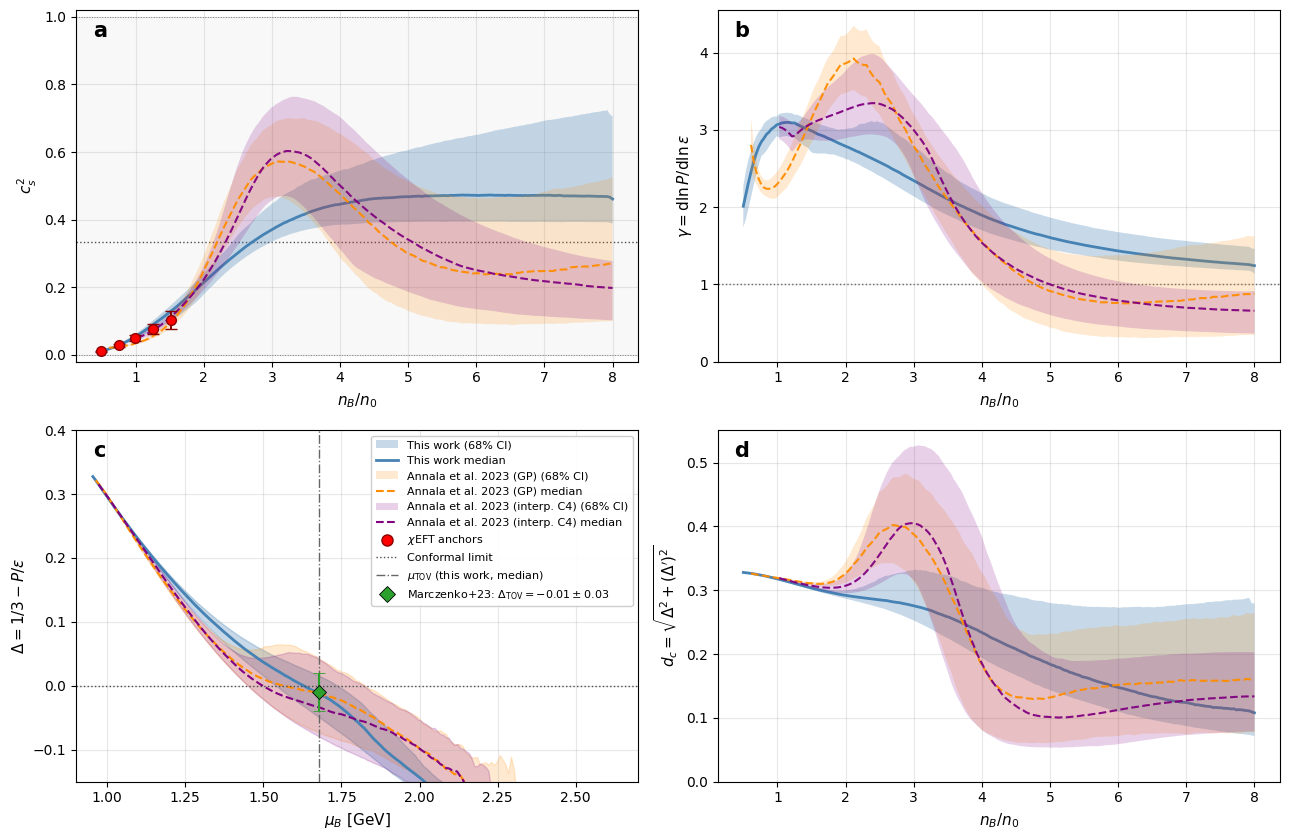

In [17]:
# =====================================================================
# Combined 2x2 diagnostics figure
#   a: cs2(nB)   b: gamma(nB)   c: Delta(mu_B)+Marczenko   d: d_c(nB)
# =====================================================================
from analysis.nature_figures import figure_diagnostics_2x2

fig_nat_diag, _ = figure_diagnostics_2x2(
    nB_grid, samples_phys, gamma_arr, dc_arr, weights,
    nB_known         = out["nB_known"],
    cs2_known        = out["cs2_known"],
    cs2_err          = cs2_err,
    external_bands   = [annala_band, annala_c4_band],
    mu_grid_MeV      = mu_grid_common,
    delta_bands_this = bands_D_this,
    delta_bands_gp   = bands_D_gp,
    delta_bands_c4   = bands_D_c4,
    mu_TOV_GeV       = mu_TOV_GeV,
    q_low = Q_LOW, q_high = Q_HIGH,
    save_path = plot_path("fig_diagnostics_nature.png"),
)
plt.show()


  Nature M-R + P/P_free figure saved to plots/fig_mr_pfree_nature.png


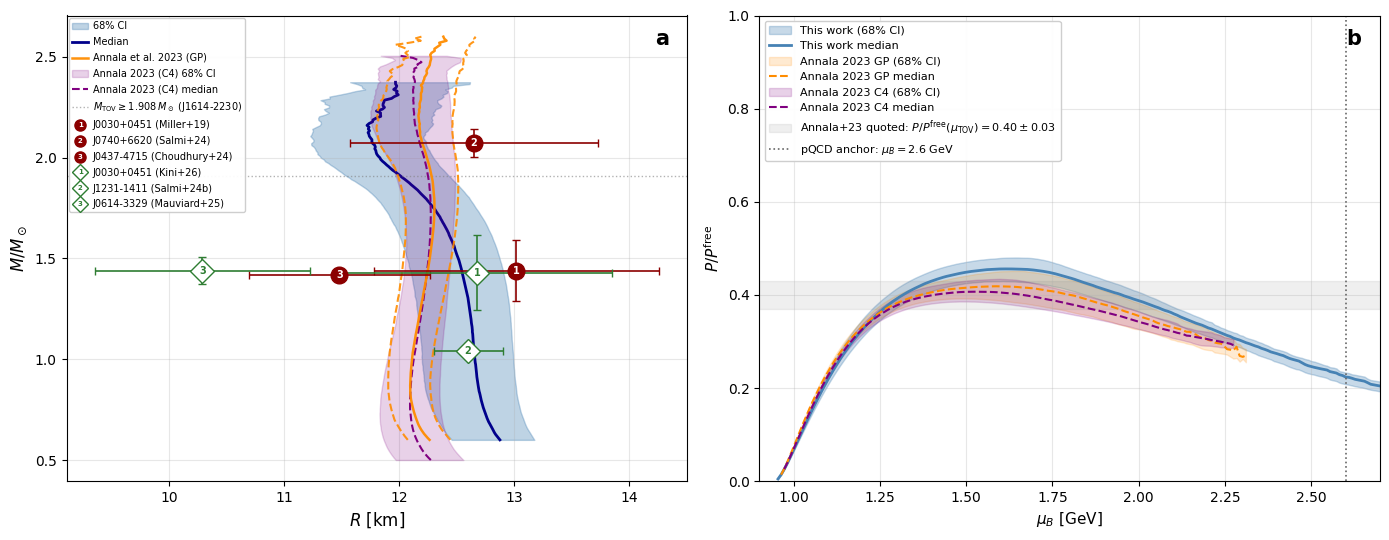

In [18]:
# =====================================================================
# Mass-radius (a) | P/P_free (b) figure
# =====================================================================
from analysis.nature_figures import figure_mr_pfree

# ---- C4 M-R band ----
radius_MASS_c4 = np.load(f"{ANNALA_C4_DIR}/radius_MASS.npy")
mass_grid_c4   = np.load(f"{ANNALA_C4_DIR}/mass_grid.npy")
R_c4_mr = radius_MASS_c4.astype(np.float64).copy()
R_c4_mr[R_c4_mr <= 0] = np.nan
if radius_MASS_c4.shape[0] == np.asarray(ext_c4["weights"]).shape[0]:
    w_c4_mr = np.asarray(ext_c4["weights"], dtype=np.float64)
else:
    w_c4_mr = np.ones(radius_MASS_c4.shape[0], dtype=np.float64)
bands_c4_mr = _wband(R_c4_mr, w_c4_mr)


fig_nat_mr, _ = figure_mr_pfree(
    M_arr, R_arr, weights,
    observed_pulsars  = nicer_all,
    mr_external_bands = [annala_mr],
    c4_mass_grid      = mass_grid_c4,
    c4_R_bands        = bands_c4_mr,
    mu_grid_MeV       = mu_grid_common,
    pfree_bands_this  = pfree_this,
    pfree_bands_gp    = pfree_gp,
    pfree_bands_c4    = pfree_c4,
    q_low = Q_LOW, q_high = Q_HIGH,
    min_weight_frac = 0., M_max_quantile = 0.995,
    save_path = plot_path("fig_mr_pfree_nature.png"),
)
plt.show()


## 15. Master fiducials

Numerical comparison of this work against published EOS-inference
results, covering the standard set of benchmarks the community reports.

## 15.1  Literature values


In [19]:
import numpy as np
import pandas as pd

pd.set_option("display.width",        220)
pd.set_option("display.max_colwidth", 80)


# ----------------------------------------------------------------
# Literature values for the side-by-side comparison column.
#
# CI levels.  Everything in this notebook is reported at 68% CI
# (the 16/84 percentiles, q16/q84), matching the bands set by
# Q_LOW, Q_HIGH = 0.16, 0.84.  Published literature values that were
# originally quoted at a wider credibility have been rescaled to 68%
# assuming an approximately Gaussian marginal, scaling each error bar
# by the ratio of z-scores (target = 16/84 percentile, z=0.9945):
#   90% CI (z=1.6449) -> 68% CI :  factor 0.6046
#   95% CI (z=1.9600) -> 68% CI :  factor 0.5074
# Original published intervals (pre-rescaling):
#   * Legred+21  (PRD 104, 063003; arXiv:2106.05313) -- published 90% CI
#   * Pang+21    (ApJ 922, 14; arXiv:2105.08688) -- published 90% CI, Table 1
#   * Pang+23    (Nat. Commun. 14, 8458; arXiv:2205.08513) -- published 90% CI for 1D marginals
#   * Koehn+25   (PRX 15, 021014; arXiv:2402.04172) -- published 95% CI;
#                  Set C ("all constraints") is the headline result.
#
# This work and the Annala GP/C4 reprocessed ensembles use 68% CI
# (q16, q84), so all comparisons are on the same footing.
# ----------------------------------------------------------------
LITERATURE_VALUES = {
    "R(1.4)":      {"Legred+21": "12.56 +0.61 -0.65",        # PRD 104, 063003; arXiv:2106.05313 (orig. 90% -> 68%)
                    "Pang+21":   "11.94 +0.46 -0.53",        # ApJ 922, 14 Table 1 (orig. 90% -> 68%)
                    "Pang+23":   "11.98 +0.21 -0.24",        # arXiv:2205.08513 abstract (orig. 90% -> 68%)
                    "Koehn+25":  "12.17 +0.23 -0.26"},       # PRX 15, 021014 Table III, Set C (orig. 95% -> 68%)
    "R(2.08)":      {"Legred+21": "12.41 +0.60 -0.66",        # orig. 90% -> 68%
                    "Pang+21":   "11.96 +0.80 -0.75 (R(2.08))"},  # cited in Kojo+22
    "Lambda(1.4)": {"Legred+21": "507 +141 -146"},            # orig. 90% -> 68%
    "M_TOV":       {"Legred+21": "2.21 +0.19 -0.13",         # PRD 104, 063003; arXiv:2106.05313 (orig. 90% -> 68%)
                    "Pang+21":   "2.18 +0.10 -0.08",         # ApJ 922, 14 Table 1 combined (orig. 90% -> 68%)
                    "Koehn+25":  "2.30 +0.04 -0.10"},        # PRX 15, 021014 Table III, Set C (orig. 95% -> 68%)
    "n_TOV/n0":    {"Koehn+25":  "5.73 +0.48 -0.42"},        # PRX 15, 021014 Table III, Set C (orig. 95% -> 68%)
    "L":           {"Tsang+24 Nat.Astron.": "83.6 +19.2 -16.8",
                    "Drischler+21":         "59.8 +/- 4.1",
                    "Koehn+25":             "48 +11 -13"},   # PRX 15, 021014 Table III, Set C (orig. 95% -> 68%)
    "d_c(TOV)":    {"Annala+23":  "approx. 0.2 (deconfinement threshold)"},
    "Delta(TOV)":  {"Fujimoto+22 PRL": "approx. 0 (conformal)"},
}


## 15.2  Helper functions

`_stable_indices` and `_interp_R_or_Lambda` reproduce the stable-branch
logic of `reweighting._stable_branch` / `pqcd._stable_branch_last_index`,
so values at target mass are read off the same monotone-non-decreasing
prefix the reweighter used.


In [20]:
def _stable_indices(M_row):
    '''Indices into the P_c grid for the stable branch (monotone-non-decreasing M).'''
    M = np.asarray(M_row, dtype=np.float64)
    finite = np.isfinite(M)
    if finite.sum() < 2:
        return np.array([], dtype=int)
    orig_idx = np.where(finite)[0]
    M_f = M[finite]
    M_cm = np.maximum.accumulate(M_f)
    stable = (M_f >= M_cm - 1e-6)
    if not stable.any():
        return np.array([], dtype=int)
    return orig_idx[stable]


def _interp_R_or_Lambda(M_row, Y_row, M_target):
    '''R or Lambda at target mass on one sample's stable branch.'''
    idx = _stable_indices(M_row)
    if idx.size < 2:
        return np.nan
    M_s = M_row[idx]
    Y_s = np.asarray(Y_row, dtype=np.float64)[idx]
    if M_target < M_s.min() or M_target > M_s.max():
        return np.nan
    return float(np.interp(M_target, M_s, Y_s))


## 15.3  Per-sample fiducial extraction

`compute_fiducials_per_sample` is the workhorse.  Given the per-sample
arrays already in the kernel, it returns a `dict` of `(N,)` arrays --
one value per posterior sample -- with `NaN` where a quantity is
undefined for that sample (e.g. $R(2.08\,M_\odot)$ when the stable branch
tops out below $2.08\,M_\odot$).

`L` is extracted in `analysis.diagnostics`:
the reconstructed total $\beta$-equilibrium energy density is inverted
(subtracting the lepton contribution) to give $E_\mathrm{sym}(n)$, which is
fit to $E_\mathrm{sym}=J+L\chi+\tfrac12 K_\mathrm{sym}\chi^2$ with
$\chi=(n-n_0)/(3n_0)$, and $L$ read off as the $\chi$-coefficient.  The
symmetric-matter baseline $E_0(n)$ comes from the BUQEYE $\chi$EFT outputs.

TOV-center diagnostics read off $c_s^2$, $d_c$, $\Delta$, and $\gamma$ at
$n_\mathrm{TOV}$ -- the central density of the maximum-mass star.
$c_s^2(n_\mathrm{TOV})$ is interpolated from the per-sample $c_s^2(n_B)$
curve and the others from `dc_arr`, `Delta_arr`, `gamma_arr`.
$n_\mathrm{TOV}$ is cached as `out["reweighting"]["pqcd_n_T"]` whenever
`PQCD_CONFIG["n_T_over_n0"]="n_TOV"` (the default in `run_sampling.py`).

In [21]:
# L extraction (analysis.diagnostics): compute_L_per_sample_textmethod recovers
# E_sym(n) from the beta-eq energy density and fits L; symmetric_matter_baseline
# supplies the BUQEYE SNM baseline E0(nB).
from analysis import (compute_L_per_sample_textmethod,
                      symmetric_matter_baseline)

BUQEYE_INPUT_DIR = "chEFT"      # folder holding the BUQEYE .npy files
_LAMBDA = 500

def _E0_sym_grid(nB_grid, n0):
    """BUQEYE SNM baseline E0(nB) for this run's directory and cutoff."""
    return symmetric_matter_baseline(nB_grid, n0,
                                     buqeye_dir=BUQEYE_INPUT_DIR, Lambda=_LAMBDA)


In [22]:
# ============================================================================
#  Symmetry-energy slope L (text method): reports L, J = E_sym(n0) and Ksym,
#  posterior-weighted and then with uniform weights (chi-EFT-anchor closure).
# ============================================================================
_E0_L = _E0_sym_grid(nB_grid, N0_DEFAULT)                       # BUQEYE SNM baseline (mean)
L_per_sample, J_per_sample, Ksym_per_sample = compute_L_per_sample_textmethod(
    eps_arr, nB_grid, _E0_L, n0=N0_DEFAULT, return_JLK=True)

_wL = np.asarray(weights, dtype=float)
_okL = np.isfinite(L_per_sample) & (_wL > 0)
if _okL.sum() == 0:
    print("!! L could NOT be extracted: every per-sample beta-eq inversion returned NaN.")
    print("   Most likely eps_arr is in the wrong units.")
    print("   Expected: total energy density in MeV/fm^3 INCLUDING rest mass (~150 at n0).")
    print(f"   Your eps_arr[0] near n0 is ~ {float(np.interp(1.0, nB_grid, eps_arr[0])):.4g} MeV/fm^3")
else:
    print("=" * 60)
    print("  SYMMETRY-ENERGY SLOPE  (text method, posterior-weighted)")
    print("=" * 60)
    for _name, _arr in [("L", L_per_sample),
                        ("J = Esym(n0)", J_per_sample),
                        ("Ksym", Ksym_per_sample)]:
        _q16, _med, _q84 = _weighted_quantiles(_arr, _wL)
        print(f"  {_name:14s} = {_med:8.1f}  +{_q84 - _med:.1f} / -{_med - _q16:.1f}  MeV")
    print(f"  [extraction OK for {int(np.isfinite(L_per_sample).sum())}/{len(L_per_sample)}; "
          f"{_okL.sum()} carry non-zero posterior weight = 100% of the posterior]")
    print("  (J should be ~31-33 MeV -- confirms the chi-EFT reference-point / mass convention)")
    print("=" * 60)

    # --- prior / closure: uniform weights => chiEFT anchors only ---
    _Lf = L_per_sample[np.isfinite(L_per_sample)]
    _p16, _pmed, _p84 = np.percentile(_Lf, [16, 50, 84])
    print("  SYMMETRY-ENERGY SLOPE  (prior: chiEFT anchors only, uniform weights)")
    print(f"  L = {_pmed:.1f}  +{_p84 - _pmed:.1f} / -{_pmed - _p16:.1f}  MeV   (closure value)")
    print(f"  [{_Lf.size} samples;]")
    print("=" * 60)


  [L extraction] E0 baseline = BUQEYE chi-EFT (Lambda=500, EA_SNM_Lambda-500_samples_N3LO.npy)
  SYMMETRY-ENERGY SLOPE  (text method, posterior-weighted)
  L              =     60.5  +7.5 / -7.6  MeV
  J = Esym(n0)   =     30.6  +0.6 / -0.7  MeV
  Ksym           =    -34.5  +48.4 / -50.8  MeV
  [extraction OK for 89513/89513; 19913 carry non-zero posterior weight = 100% of the posterior]
  (J should be ~31-33 MeV -- confirms the chi-EFT reference-point / mass convention)
  SYMMETRY-ENERGY SLOPE  (prior: chiEFT anchors only, uniform weights)
  L = 57.7  +8.3 / -8.3  MeV   (closure value)
  [89513 samples;]


In [23]:
# ============================================================================
#  Covariance-consistent L: directly from the BUQEYE S2_BETAEQ samples, whose
#  spread already carries the correlated PNM-SNM truncation errors, so it is
#  the honest symmetry-energy uncertainty. 
# ============================================================================
from analysis import compute_L_from_S2_samples

L_cc, J_cc, Ksym_cc = compute_L_from_S2_samples(
    buqeye_dir=BUQEYE_INPUT_DIR, Lambda=_LAMBDA, return_JLK=True)

def _pq(v):
    v = v[np.isfinite(v)]
    return np.percentile(v, [16, 50, 84])

print("=" * 60)
print("  SYMMETRY-ENERGY PARAMETERS  (covariance-consistent, chi-EFT)")
print("=" * 60)
for _name, _arr in [("L", L_cc), ("J = Esym(n0)", J_cc), ("Ksym", Ksym_cc)]:
    _q16, _med, _q84 = _pq(_arr)
    print(f"  {_name:14s} = {_med:8.1f}  +{_q84 - _med:.1f} / -{_med - _q16:.1f}  MeV")
print("=" * 60)
print("  This L width is the honest SNM-truncation-inclusive symmetry-energy")
print("  uncertainty (PNM-SNM correlation intact).  Compare:")
print("   - EOS-inversion prior, mean baseline : L = 56.8 MeV  (consistency check)")
print("  The covariance-consistent width is the systematic to quote; it also")
print("  bounds the SNM effect on the astro posterior (chiral-dominated at n0).")
print("=" * 60)


  [L cov-consistent] from S2_BETAEQ (Lambda=500, 20000 draws): L = 57.9 +3.0/-3.0 MeV  (chi-EFT, correlation intact)
  SYMMETRY-ENERGY PARAMETERS  (covariance-consistent, chi-EFT)
  L              =     57.9  +3.0 / -3.0  MeV
  J = Esym(n0)   =     30.5  +0.4 / -0.3  MeV
  Ksym           =    -63.9  +20.9 / -20.6  MeV
  This L width is the honest SNM-truncation-inclusive symmetry-energy
  uncertainty (PNM-SNM correlation intact).  Compare:
   - EOS-inversion prior, mean baseline : L = 56.8 MeV  (consistency check)
  The covariance-consistent width is the systematic to quote; it also
  bounds the SNM effect on the astro posterior (chiral-dominated at n0).


In [24]:
def compute_fiducials_per_sample(
        *, samples_phys, P_arr, eps_arr,
        gamma_arr, Delta_arr, dc_arr,
        M_arr, R_arr, Lambda_arr,
        nB_grid,
        n_TOV_phys = None,
        M_TOV_arr  = None,
        target_masses        = (1.4, 1.6, 2.08),
        n0            = N0_DEFAULT,
        compute_L     = True):
    """One value per posterior sample for every fiducial quantity.
    """
    samples_phys = np.asarray(samples_phys, dtype=np.float64)
    P_arr        = np.asarray(P_arr,        dtype=np.float64)
    eps_arr      = np.asarray(eps_arr,      dtype=np.float64)
    gamma_arr    = np.asarray(gamma_arr,    dtype=np.float64)
    Delta_arr    = np.asarray(Delta_arr,    dtype=np.float64)
    dc_arr       = np.asarray(dc_arr,       dtype=np.float64)
    M_arr        = np.asarray(M_arr,        dtype=np.float64)
    R_arr        = np.asarray(R_arr,        dtype=np.float64)
    Lambda_arr   = np.asarray(Lambda_arr,   dtype=np.float64)
    nB_grid      = np.asarray(nB_grid,      dtype=np.float64)

    N, L = samples_phys.shape
    out = {}

    # ---- stellar fiducials at fixed mass --------------------------
    for m in target_masses:
        out[f"R({m})"]      = np.array(
            [_interp_R_or_Lambda(M_arr[n], R_arr[n],      m) for n in range(N)])
        out[f"Lambda({m})"] = np.array(
            [_interp_R_or_Lambda(M_arr[n], Lambda_arr[n], m) for n in range(N)])

    out["M_TOV"] = (np.asarray(M_TOV_arr, dtype=np.float64).copy()
                    if M_TOV_arr is not None
                    else np.nanmax(M_arr, axis=1))

    # Peak speed of sound and the density at which it occurs.
    # Computed per-sample so that the same machinery
    # (compute_fiducials_per_sample -> build_fiducials_dataframe)
    # produces weighted 68% CIs for `this work`, Annala GP, and Annala C4
    # automatically.  Using nanargmax to skip masked grid points
    # (e.g. ext_c4 entries flagged via `in_range`).
    with np.errstate(invalid="ignore"):
        out["cs2_max"]   = np.nanmax(samples_phys, axis=1)
        peak_idx         = np.nanargmax(samples_phys, axis=1)
    out["n_peak/n0"] = nB_grid[peak_idx]

    # ---- symmetry-energy slope (L) --------------------------------
    # Recover E_sym(n) from the beta-eq energy density and fit
    # E_sym = J + L*chi + 1/2 Ksym*chi^2, chi = (n-n0)/(3 n0); 
    # Meaningful for this work only -- Annala's ensembles carry no
    # composition decomposition, so _annala_to_per_sample sets compute_L=False.
    if compute_L:
        out["L"] = compute_L_per_sample_textmethod(
            eps_arr, nB_grid, _E0_sym_grid(nB_grid, n0), n0=n0)
    else:
        out["L"] = np.full(N, np.nan)

    # ---- TOV-center diagnostics (cs2, d_c, Delta, gamma) ----------
    # samples_phys IS the per-sample c_s^2(nB) curve, so cs2(TOV) comes from the
    # same per-sample interpolation at n_TOV used for d_c / Delta / gamma.
    if n_TOV_phys is not None:
        n_TOV_over_n0 = np.asarray(n_TOV_phys, dtype=np.float64) / n0
        out["n_TOV/n0"] = n_TOV_over_n0.copy()
        cs2_TOV   = np.full(N, np.nan)
        d_c_TOV   = np.full(N, np.nan)
        Delta_TOV = np.full(N, np.nan)
        gamma_TOV = np.full(N, np.nan)
        for n in range(N):
            nbt = n_TOV_over_n0[n]
            if not np.isfinite(nbt) or nbt < nB_grid.min() or nbt > nB_grid.max():
                continue
            cs2_TOV[n]   = float(np.interp(nbt, nB_grid, samples_phys[n]))
            d_c_TOV[n]   = float(np.interp(nbt, nB_grid, dc_arr[n]))
            Delta_TOV[n] = float(np.interp(nbt, nB_grid, Delta_arr[n]))
            gamma_TOV[n] = float(np.interp(nbt, nB_grid, gamma_arr[n]))
        out["d_c(TOV)"]   = d_c_TOV
        out["Delta(TOV)"] = Delta_TOV
        out["gamma(TOV)"] = gamma_TOV
        out["cs2(TOV)"]   = cs2_TOV
    else:
        out["n_TOV/n0"]   = np.full(N, np.nan)
        out["d_c(TOV)"]   = np.full(N, np.nan)
        out["Delta(TOV)"] = np.full(N, np.nan)
        out["gamma(TOV)"] = np.full(N, np.nan)
        out["cs2(TOV)"]   = np.full(N, np.nan)

    return out


## 15.4  Aggregation and formatting

`build_fiducials_dataframe` reduces the per-sample arrays to (median, q16, q84)
under self-normalised importance sampling.  `format_comparison_table` stacks
multiple sources side-by-side and appends literature columns.

In [25]:
def build_fiducials_dataframe(per_sample, weights, *,
                                label="this work",
                                quantile_low=0.16,
                                quantile_high=0.84,
                                P_PT=None,
                                P_PT_prior=None):
    '''Per-sample arrays -> DataFrame with weighted (median, q16, q84) at 68% CI.'''
    weights = np.asarray(weights, dtype=np.float64)
    rows = {}
    for qty, vals in per_sample.items():
        q_lo, med, q_hi = _weighted_quantiles(
            vals, weights, qs=(quantile_low, 0.5, quantile_high))
        rows[qty] = (med, q_lo, q_hi)

    if P_PT is not None:
        rows["P_PT"] = (P_PT, np.nan, np.nan)
    if P_PT is not None and P_PT_prior is not None:
        eps_floor = 1e-3
        post_odds  = P_PT       / max(1.0 - P_PT,       eps_floor)
        prior_odds = P_PT_prior / max(1.0 - P_PT_prior, eps_floor)
        if prior_odds > 0:
            rows["BF(PT vs no-PT)"] = (post_odds / prior_odds, np.nan, np.nan)

    qlo = f"q{int(100 * quantile_low)}"
    qhi = f"q{int(100 * quantile_high)}"
    df = pd.DataFrame.from_dict(
        rows, orient="index", columns=["median", qlo, qhi])
    df.columns = pd.MultiIndex.from_product([[label], df.columns])
    return df


def format_comparison_table(dataframes, literature=None,
                              precision=2, show_ci=True):
    '''Stack source DataFrames side-by-side; append literature columns.'''
    # Build the union of row indices preserving order
    index_order = []
    seen = set()
    for df in dataframes:
        for q in df.index:
            if q not in seen:
                index_order.append(q)
                seen.add(q)
    if literature:
        for q in literature.keys():
            if q not in seen:
                index_order.append(q)
                seen.add(q)

    out = pd.DataFrame(index=index_order)

    def _fmt(med, qlo, qhi):
        if not np.isfinite(med):
            return "--"
        if (not np.isfinite(qlo)) or (not np.isfinite(qhi)) or (not show_ci):
            return f"{med:.{precision}f}"
        return f"{med:.{precision}f} +{qhi - med:.{precision}f} -{med - qlo:.{precision}f}"

    for df in dataframes:
        label = df.columns.get_level_values(0)[0]
        col = []
        for q in index_order:
            if q in df.index:
                med = df.loc[q, (label, "median")]
                qlo_name = df.columns.get_level_values(1)[1]
                qhi_name = df.columns.get_level_values(1)[2]
                col.append(_fmt(med, df.loc[q, (label, qlo_name)],
                                     df.loc[q, (label, qhi_name)]))
            else:
                col.append("--")
        out[label] = col

    if literature:
        paper_labels = []
        for papers in literature.values():
            for paper in papers:
                if paper not in paper_labels:
                    paper_labels.append(paper)
        for paper in paper_labels:
            out[paper] = [literature.get(q, {}).get(paper, "--")
                          for q in index_order]

    return out


## 15.5  Fiducials for this work

`pqcd_n_T` is the TOV central baryon density in fm$^{-3}$, cached by
`pqcd_term` when `PQCD_CONFIG["n_T_over_n0"]="n_TOV"` (the default in
`run_sampling.py`).  Used here to evaluate $d_c$, $\Delta$, $\gamma$
at the TOV center.  `M_max_pred` is the per-sample $M_\mathrm{TOV}$ also
cached by the reweighter.

In [26]:
n_TOV_phys = out["reweighting"].get("pqcd_n_T", None)
M_TOV_arr  = out["reweighting"].get("M_max_pred", None)

per_sample_this = compute_fiducials_per_sample(
    samples_phys = samples_phys,
    P_arr        = P_arr,
    eps_arr      = eps_arr,
    gamma_arr    = gamma_arr,
    Delta_arr    = Delta_arr,
    dc_arr       = dc_arr,
    M_arr        = M_arr,
    R_arr        = R_arr,
    Lambda_arr   = Lambda_arr,
    nB_grid      = nB_grid,
    n_TOV_phys   = n_TOV_phys,
    M_TOV_arr    = M_TOV_arr,
)

df_this = build_fiducials_dataframe(
    per_sample_this, weights,
    label      = "this work",
    P_PT       = P_post,
    P_PT_prior = P_prior,
)
print("=" * 64)
print("  Fiducial quantities -- this work")
print("=" * 64)
print(df_this)


_w = np.asarray(weights, dtype=float)
_w = _w / _w.sum()

#  cs2_max is the peak over the WHOLE nB grid (to 8 n0), not up to
#      n_TOV, so it can sit at a density no star reaches. 
_npeak = per_sample_this.get("n_peak/n0", None)
_nTOV  = per_sample_this.get("n_TOV/n0",  None)
if _npeak is not None and _nTOV is not None:
    _ok = np.isfinite(_npeak) & np.isfinite(_nTOV) & (_w > 0)
    if _ok.any():
        _above = _ok & (_npeak > _nTOV)
        _frac_w = _w[_above].sum() / _w[_ok].sum()
        print(f"  c_s^2 peak sits ABOVE n_TOV for "
              f"{100.0 * _frac_w:.1f}% of the posterior weight")
        print("=" * 64)


  [L extraction] E0 baseline = BUQEYE chi-EFT (Lambda=500, EA_SNM_Lambda-500_samples_N3LO.npy)
  Fiducial quantities -- this work
                  this work                        
                     median         q16         q84
R(1.4)            12.560316   12.113933   12.916957
Lambda(1.4)      468.904051  369.144922  566.210712
R(1.6)            12.448237   12.011275   12.812039
Lambda(1.6)      193.494259  151.087107  235.524607
R(2.08)           11.762524   11.252294   12.234184
Lambda(2.08)      18.887287   12.682772   27.058589
M_TOV              2.055308    1.979255    2.151940
cs2_max            0.547760    0.427543    0.780806
n_peak/n0          6.115578    4.155779    7.924623
L                 60.535026   52.888208   68.027410
n_TOV/n0           6.380890    5.931842    6.850114
d_c(TOV)           0.134885    0.105891    0.274551
Delta(TOV)        -0.009651   -0.097149    0.034663
gamma(TOV)         1.389079    1.292541    1.593770
cs2(TOV)           0.472298    0.39345

## 15.6  Sound speed at the TOV centre and grid edge


In [27]:
# ============================================================================
#  Sound speed at the TOV centre and at the grid edge
# ============================================================================
_xd = np.asarray(nB_grid, float)

# c_s^2 at the TOV centre: each sample's c_s^2 curve at its own n_TOV.
_nT = out["reweighting"].get("pqcd_n_T", None)
if _nT is not None:
    _nTn0 = np.asarray(_nT, float) / N0_DEFAULT
    _cs2_T = np.array([
        np.interp(nb, _xd, samples_phys[n])
        if (np.isfinite(nb) and _xd.min() <= nb <= _xd.max()) else np.nan
        for n, nb in enumerate(_nTn0)])
    cs2T_lo, cs2T_med, cs2T_hi = _weighted_quantiles(_cs2_T, weights, qs=(0.16, 0.5, 0.84))
else:
    cs2T_lo = cs2T_med = cs2T_hi = float("nan")

# c_s^2 at the grid edge (8 n0): each sample's curve evaluated at nB/n0 = 8.
_cs2_8 = np.array([np.interp(8.0, _xd, samples_phys[n])
                   for n in range(samples_phys.shape[0])])
cs28_lo, cs28_med, cs28_hi = _weighted_quantiles(_cs2_8, weights, qs=(0.16, 0.5, 0.84))

print("=" * 64)
print("  SOUND SPEED FOR THE CONFORMALITY PARAGRAPH  (weighted median, 68% CI)")
print("=" * 64)
print(f"  c_s^2(TOV)  = {cs2T_med:.2f}  +{cs2T_hi - cs2T_med:.2f} -{cs2T_med - cs2T_lo:.2f}"
      f"    (conformal value 1/3 = {1.0/3.0:.2f})")
print(f"  c_s^2(8 n0) = {cs28_med:.2f}  +{cs28_hi - cs28_med:.2f} -{cs28_med - cs28_lo:.2f}")
print()
print("=" * 64)


  SOUND SPEED FOR THE CONFORMALITY PARAGRAPH  (weighted median, 68% CI)
  c_s^2(TOV)  = 0.47  +0.21 -0.08    (conformal value 1/3 = 0.33)
  c_s^2(8 n0) = 0.46  +0.24 -0.07



## 15.7  Annala 2023 GP and C4 ensembles


In [28]:
def _to_float_2d(obj_arr):
    """Object-dtype 2D array -> float64; None elements -> NaN."""
    if obj_arr is None or getattr(obj_arr, "size", 0) == 0:
        return None
    if obj_arr.dtype != object:
        return np.asarray(obj_arr, dtype=np.float64)
    flat = obj_arr.flatten()
    out_flat = np.array(
        [np.nan if x is None else float(x) for x in flat],
        dtype=np.float64)
    return out_flat.reshape(obj_arr.shape)


def _prefer_published(ext, key_published, fallback_arr, label):
    """Return ext[key_published] if it is a valid 2D float array;
    otherwise fall back to fallback_arr and print which path was used."""
    pub = ext.get(key_published, None)
    if pub is None or (hasattr(pub, "size") and pub.size == 0):
        print(f"      {label}: published unavailable -> recomputed algebraically")
        return fallback_arr
    pub = np.asarray(pub, dtype=np.float64)
    if pub.shape != fallback_arr.shape:
        print(f"      {label}: published shape {pub.shape} != "
              f"expected {fallback_arr.shape} -> recomputed")
        return fallback_arr
    print(f"      {label}: using Annala published values")
    return pub


def _annala_to_per_sample(ext, name="(ensemble)"):
    """Run compute_fiducials_per_sample on an Annala ensemble dict.

    For gamma and d_c: prefers Annala's `*_published` arrays when the
    loader exposes them (C4 case).  Otherwise reconstructs algebraically
    from cs2/P/eps.

    For Delta: always reconstructed -- Annala does not ship Delta even
    for C4 (only gamma and dc), and Delta = 1/3 - P/eps is exact.
    """
    print(f"  Annala adapter for {name}:")
    cs2_e = np.asarray(ext["cs2_arr"], dtype=np.float64)
    P_e   = np.asarray(ext["P_arr"],   dtype=np.float64)
    eps_e = np.asarray(ext["eps_arr"], dtype=np.float64)
    nB_e  = np.asarray(ext["target_grid"], dtype=np.float64)

    # Mask out-of-range grid points with NaN so peak finder and
    # saturation fit skip them.
    in_range_mask = np.asarray(
        ext.get("in_range", np.ones(cs2_e.shape[1], dtype=bool)),
        dtype=bool)
    cs2_e = np.where(in_range_mask[None, :], cs2_e, np.nan)
    P_e   = np.where(in_range_mask[None, :], P_e,   np.nan)
    eps_e = np.where(in_range_mask[None, :], eps_e, np.nan)

    # Algebraic fallbacks (used when *_published is not in the loader)
    P_safe   = np.maximum(P_e,   1e-12)
    eps_safe = np.maximum(eps_e, 1e-12)
    gamma_calc = cs2_e * eps_e / P_safe
    Delta_calc = 1.0/3.0 - P_e / eps_safe
    Dprime_e   = P_e / eps_safe - cs2_e
    dc_calc    = np.sqrt(Delta_calc**2 + Dprime_e**2)

    # Prefer published values where available
    gamma_e = _prefer_published(ext, "gamma_published", gamma_calc, "gamma")
    Delta_e = _prefer_published(ext, "Delta_published", Delta_calc, "Delta")
    dc_e    = _prefer_published(ext, "dc_published",    dc_calc,    "d_c")

    # Apply in_range mask to any published arrays too.Published arrays may
    # already have zeros outside in_range; we override with NaN to make
    # downstream NaN-aware operations behave correctly.)
    gamma_e = np.where(in_range_mask[None, :], gamma_e, np.nan)
    Delta_e = np.where(in_range_mask[None, :], Delta_e, np.nan)
    dc_e    = np.where(in_range_mask[None, :], dc_e,    np.nan)

    # Stellar arrays: convert ragged object dtype to float
    N_e = cs2_e.shape[0]
    M_e      = _to_float_2d(ext.get("M_arr"))
    R_e      = _to_float_2d(ext.get("R_arr"))
    Lambda_e = _to_float_2d(ext.get("Lambda_arr"))
    if M_e is None or R_e is None or Lambda_e is None:
        n_c = 50
        M_e      = np.full((N_e, n_c), np.nan)
        R_e      = np.full((N_e, n_c), np.nan)
        Lambda_e = np.full((N_e, n_c), np.nan)

    return compute_fiducials_per_sample(
        samples_phys = cs2_e,
        P_arr        = P_e,
        eps_arr      = eps_e,
        gamma_arr    = gamma_e,
        Delta_arr    = Delta_e,
        dc_arr       = dc_e,
        M_arr        = M_e,
        R_arr        = R_e,
        Lambda_arr   = Lambda_e,
        nB_grid      = nB_e,
        n_TOV_phys   = None,
        M_TOV_arr    = np.asarray(ext["M_TOV"], dtype=np.float64),
        compute_L    = False,   # L is `this work` only (see compute_fiducials_per_sample)
    )


try:
    per_sample_gp = _annala_to_per_sample(ext_gp, name="Annala GP")
    w_gp = np.asarray(ext_gp["weights"], dtype=np.float64)
    df_annala_gp = build_fiducials_dataframe(
        per_sample_gp, w_gp, label="Annala GP")
    print(f"  -> OK  (N={ext_gp['N']}, finite weights="
          f"{int((w_gp > 0).sum())})")
except Exception as e:
    print(f"  -> Annala GP skipped ({type(e).__name__}: {e})")
    df_annala_gp = None

try:
    per_sample_c4 = _annala_to_per_sample(ext_c4, name="Annala C4")
    w_c4 = np.asarray(ext_c4["weights"], dtype=np.float64)
    df_annala_c4 = build_fiducials_dataframe(
        per_sample_c4, w_c4, label="Annala C4")
    print(f"  -> OK  (N={ext_c4['N']}, finite weights="
          f"{int((w_c4 > 0).sum())})")
except Exception as e:
    print(f"  -> Annala C4 skipped ({type(e).__name__}: {e})")
    df_annala_c4 = None


  Annala adapter for Annala GP:
      gamma: published unavailable -> recomputed algebraically
      Delta: published unavailable -> recomputed algebraically
      d_c: published unavailable -> recomputed algebraically
  -> OK  (N=120000, finite weights=42824)
  Annala adapter for Annala C4:
      gamma: using Annala published values
      Delta: published unavailable -> recomputed algebraically
      d_c: using Annala published values
  -> OK  (N=9070, finite weights=9070)


## 15.8  Master comparison table

This work alongside the reprocessed Annala GP and C4 ensembles -- one
column each. `--` marks a quantity not defined for that source.
Rendered as a scrollable HTML table in the notebook.


In [29]:
sources = [df_this]
if df_annala_gp is not None: sources.append(df_annala_gp)
if df_annala_c4 is not None: sources.append(df_annala_c4)

table = format_comparison_table(
    sources,
    literature = None,
    precision  = 2,
    show_ci    = True,
)

# Render as a proper (scrollable) HTML table in the notebook.
from IPython.display import display

styled = (
    table.style
    .set_caption("Master fiducials comparison table (weighted median, 68% CI)")
    .set_properties(**{"text-align": "left", "white-space": "nowrap"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-weight", "bold"), ("font-size", "13px"),
                   ("text-align", "left"), ("padding", "6px 2px")]},
        {"selector": "th",
         "props": [("text-align", "left"), ("padding", "2px 12px"),
                   ("border-bottom", "1px solid #ddd")]},
        {"selector": "td",
         "props": [("text-align", "left"), ("padding", "2px 12px")]},
    ])
)
display(styled)


,this work,Annala GP,Annala C4
R(1.4),12.56 +0.36 -0.45,12.24 +0.18 -0.22,12.24 +0.20 -0.20
Lambda(1.4),468.90 +97.31 -99.76,464.80 +42.06 -68.05,--
R(1.6),12.45 +0.36 -0.44,12.29 +0.19 -0.23,12.27 +0.19 -0.21
Lambda(1.6),193.49 +42.03 -42.41,204.84 +28.14 -30.92,--
R(2.08),11.76 +0.47 -0.51,12.20 +0.27 -0.37,12.16 +0.30 -0.40
Lambda(2.08),18.89 +8.17 -6.20,30.36 +7.40 -7.86,--
M_TOV,2.06 +0.10 -0.08,2.23 +0.14 -0.11,--
cs2_max,0.55 +0.23 -0.12,0.66 +0.12 -0.10,0.80 +0.12 -0.16
n_peak/n0,6.12 +1.81 -1.96,3.48 +2.86 -0.57,3.18 +0.75 -0.53
L,60.54 +7.49 -7.65,--,--


## 15.9  Literature values for the forest plot

Builds `LIT_NUMERIC`: published $R(1.4)$, $\Lambda(1.4)$, $M_{\mathrm{TOV}}$, …
as `(median, q16, q84)` at 68% CI, rescaling each source's interval from its
original credibility with `to68()`. Consumed by the fiducials forest figure
(section 16).


In [30]:
# Literature values for the forest plot, as (median, q16, q84) at 68% CI.
# Each entry is the value reported in the source paper, converted to a 68%
# interval by to68(): every one-sided error bar is scaled by the z-score
# ratio for its original credibility level.
RESCALE_90_68 = 0.6046   # 90% CI -> 68%
RESCALE_95_68 = 0.5074   # 95% CI -> 68%
NO_RESCALE    = 1.0      # already reported at 68% (q16/q84)

def to68(median, plus, minus, factor):
    """Published CI (upper +plus, lower -minus) -> (median, q16, q84) at 68%."""
    return (median, round(median - minus * factor, 2), round(median + plus * factor, 2))

LIT_NUMERIC = {
    "R(1.4)": {
        "Legred+21":          to68(12.56, 1.00, 1.07, RESCALE_90_68),  # arXiv:2106.05313, Table II
        "Pang+21":            to68(11.94, 0.76, 0.87, RESCALE_90_68),  # arXiv:2105.08688, Table 1
        "Pang+23":            to68(11.98, 0.35, 0.40, RESCALE_90_68),  # arXiv:2205.08513, abstract
        "Koehn+25":           to68(12.17, 0.46, 0.51, RESCALE_95_68),  # arXiv:2402.04172, Table III (Set C)
        "Rutherford+24 (PP)": to68(12.28, 0.50, 0.76, RESCALE_95_68),  # arXiv:2407.06790, Table 1 ("New", PP)
        "Rutherford+24 (CS)": to68(12.01, 0.56, 0.75, RESCALE_95_68),  # arXiv:2407.06790, Table 1 ("New", CS)
    },
    "Lambda(1.4)": {
        "Legred+21":          to68(507, 234, 242, RESCALE_90_68),      # arXiv:2106.05313, Table II
    },
    "M_TOV": {
        "Legred+21":          to68(2.21, 0.31, 0.21, RESCALE_90_68),   # arXiv:2106.05313, Table II
        "Pang+21":            to68(2.18, 0.16, 0.13, RESCALE_90_68),   # arXiv:2105.08688, Table 1
        "Koehn+25":           to68(2.30, 0.07, 0.20, RESCALE_95_68),   # arXiv:2402.04172, Table III (Set C)
        "Rutherford+24 (PP)": to68(2.15, 0.14, 0.16, RESCALE_95_68),   # arXiv:2407.06790, Table 1 ("New", PP)
        "Rutherford+24 (CS)": to68(2.08, 0.28, 0.16, RESCALE_95_68),   # arXiv:2407.06790, Table 1 ("New", CS)
    },
}


## 16. Extended fiducials and forest plot

Augments the per_sample dicts with `Lambda_tilde` (GW170817
mass-weighted), `R` at canonical $M=2.08\,M_\odot$ (J0740), and `R(M_TOV)`,
then draws the astrophysical-observables forest figure.


  Nature forest figure saved to plots/fiducials_forest_nature.png


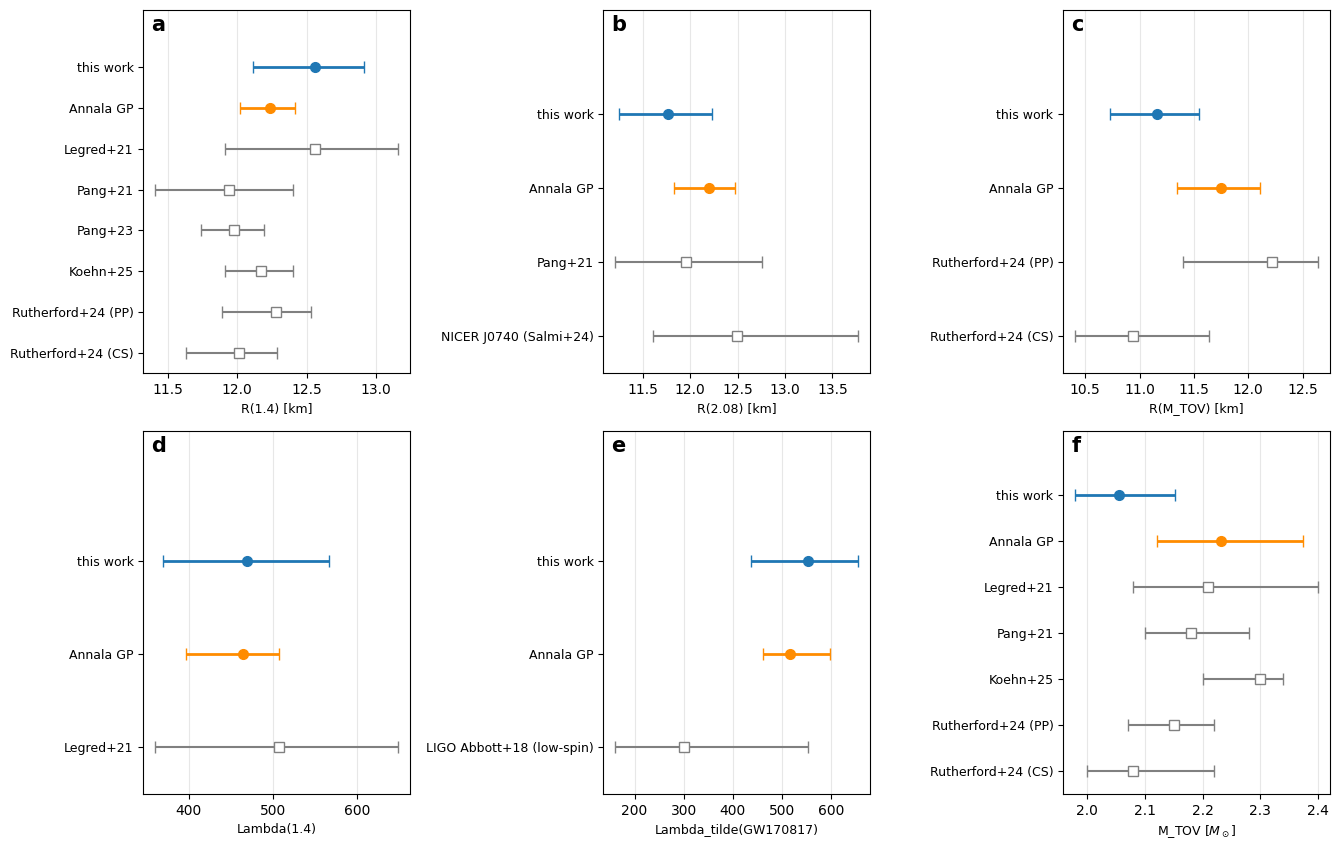

Saved fiducials_forest_nature.png  (6 panels, 3 x 2, letters a-f)


In [31]:
# ============================================================
# Extended fiducials and forest plot
# ============================================================
GW170817_M1 = 1.48      # M_sun (from astro_configs.py)
GW170817_M2 = 1.26


def augment_per_sample(per_sample, *,
                        M_arr, R_arr, Lambda_arr,
                        extra_masses = (1.8, 2.08),
                        m1_GW = GW170817_M1, m2_GW = GW170817_M2):
    """Add Lambda_tilde(GW170817), R(M_TOV), and R/Lambda at extra
    canonical masses to per_sample."""
    N = M_arr.shape[0]

    # R, Lambda at extra canonical masses
    for m in extra_masses:
        per_sample[f"R({m})"]      = np.array(
            [_interp_R_or_Lambda(M_arr[n], R_arr[n],      m) for n in range(N)])
        per_sample[f"Lambda({m})"] = np.array(
            [_interp_R_or_Lambda(M_arr[n], Lambda_arr[n], m) for n in range(N)])

    # Lambda_tilde(GW170817) + R(M_TOV)
    Ltilde = np.full(N, np.nan)
    R_TOV  = np.full(N, np.nan)
    for n in range(N):
        L1 = _interp_R_or_Lambda(M_arr[n], Lambda_arr[n], m1_GW)
        L2 = _interp_R_or_Lambda(M_arr[n], Lambda_arr[n], m2_GW)
        if np.isfinite(L1) and np.isfinite(L2):
            num = ((m1_GW + 12 * m2_GW) * m1_GW**4 * L1 +
                   (m2_GW + 12 * m1_GW) * m2_GW**4 * L2)
            den = (m1_GW + m2_GW)**5
            Ltilde[n] = (16.0 / 13.0) * num / den
        idx = _stable_indices(M_arr[n])
        if idx.size >= 2 and np.isfinite(R_arr[n, idx[-1]]):
            R_TOV[n] = float(R_arr[n, idx[-1]])
    per_sample["Lambda_tilde(GW170817)"] = Ltilde
    per_sample["R(M_TOV)"]               = R_TOV
    return per_sample


# Helper to rebuild the Annala arrays
def _annala_arrays(ext):
    M_e      = _to_float_2d(ext.get("M_arr"))
    R_e      = _to_float_2d(ext.get("R_arr"))
    Lambda_e = _to_float_2d(ext.get("Lambda_arr"))
    if M_e is None:
        # Annala C4 ships no M/R -- caller will skip augmentation.
        return None, None, None
    if R_e is None:      R_e      = np.full_like(M_e, np.nan)
    if Lambda_e is None: Lambda_e = np.full_like(M_e, np.nan)
    return M_e, R_e, Lambda_e


# ---- Apply augmentation to each ensemble ----
augment_per_sample(
    per_sample_this,
    M_arr      = M_arr,
    R_arr      = R_arr,
    Lambda_arr = Lambda_arr,
)

if df_annala_gp is not None:
    M_gp, R_gp, L_gp = _annala_arrays(ext_gp)
    if M_gp is not None:
        augment_per_sample(per_sample_gp,
                            M_arr=M_gp, R_arr=R_gp, Lambda_arr=L_gp)

if df_annala_c4 is not None:
    M_c4, R_c4, L_c4 = _annala_arrays(ext_c4)
    if M_c4 is not None:
        augment_per_sample(per_sample_c4,
                            M_arr=M_c4, R_arr=R_c4, Lambda_arr=L_c4)


# ---- Extend LIT_NUMERIC with the augmented quantities ----------------
LIT_NUMERIC.update({
    "R(2.08)": {
        "Pang+21":                to68(11.96, 0.80, 0.75, NO_RESCALE),  # arXiv:2105.08688, R_predict at J0740 mass (Miller+XMM)
        "NICER J0740 (Salmi+24)": to68(12.49, 1.28, 0.88, NO_RESCALE),  # arXiv:2406.14466, headline (16/84)
    },
    "Lambda_tilde(GW170817)": {
        "LIGO Abbott+18 (low-spin)": to68(300, 420, 230, RESCALE_90_68),  # arXiv:1805.11579 (PRX 9, 011001), low-spin HPD
    },
    "R(M_TOV)": {
        "Rutherford+24 (PP)":     to68(12.22, 0.83, 1.62, RESCALE_95_68),  # arXiv:2407.06790, Table 1 ("New", PP)
        "Rutherford+24 (CS)":     to68(10.94, 1.37, 1.04, RESCALE_95_68),  # arXiv:2407.06790, Table 1 ("New", CS)
    },
})

# ---- Forest plot  ----
from analysis.nature_figures import figure_fiducials_forest

ensemble_rows = [("this work", per_sample_this, weights, "C0")]
if df_annala_gp is not None:
    ensemble_rows.append(("Annala GP", per_sample_gp, w_gp, "darkorange"))
if df_annala_c4 is not None:
    ensemble_rows.append(("Annala C4", per_sample_c4, w_c4, "purple"))

fig_forest, _ = figure_fiducials_forest(
    quantities = ["R(1.4)", "R(2.08)", "R(M_TOV)",
                  "Lambda(1.4)", "Lambda_tilde(GW170817)", "M_TOV"],
    ensemble_rows = ensemble_rows,
    lit_numeric   = LIT_NUMERIC,
    weighted_quantiles_fn = _weighted_quantiles,
    xlabels = {"R(1.4)": "km", "R(2.08)": "km", "R(M_TOV)": "km",
               "M_TOV": r"$M_\odot$"},
    skip_ensemble = {"Annala C4": {"R(1.4)", "R(2.08)", "R(M_TOV)",
                                   "Lambda(1.4)", "Lambda_tilde(GW170817)"}},
    save_path = plot_path("fiducials_forest_nature.png"),
)
plt.show()
print("Saved fiducials_forest_nature.png  (6 panels, 3 x 2, letters a-f)")
